# 02 - The fifteen-line fix: split conformal prediction

> "Fine — give the desk a price range that is right 90% of the time. Can you promise 90%?"

That is the acquisitions desk at Hearthstone, one meeting after the events of notebook 01.
Note the word they chose: *promise*. Not "aim for", not "expect". The sharper statistical
question hiding inside the business one: given *any* point-prediction model and a finite
pile of labeled listings, can we construct what notebook 01 called a prediction interval —
a range `[lo, hi]` around each predicted price — such that the true sale price lands inside at
least 90% of the time, provably, in finite samples, without assuming the model is good and
without knowing anything about the true distribution of prices?

The answer is yes, literally promise. It costs about fifteen lines of numpy and one honest
data split. This notebook builds those fifteen lines slowly, then all at once.

**What you will learn**

- What a calibration set is, and why it is not a validation set.
- What a nonconformity score is (the weirdness meter) and the simplest one that works.
- Why the quantile needs a small `(n+1)` correction, and what happens when the calibration
  set is too small to pay for it.
- How to implement split conformal prediction end to end in fifteen lines, and how to check
  that the promise holds.
- Why the coverage guarantee is free for any model, while narrow intervals must be earned.

**Where we are in the series.** Notebook 01 watched a confident model lose money by grading
its own homework; notebook 03 explains *why* today's fix works (the leaderboard argument).

## 1. Where notebook 01 left us

Notebook 01 ended with a model that quoted tight price ranges and missed far more often
than it promised, because we measured its errors on the same listings it had trained on —
and a model's errors on its own training data are flattering (field guide §2). The desk
does not want a hope calibrated on flattery; it wants a promise that survives contact with
listings the model has never seen.

Here is the whole plan for this notebook, announced up front so you can watch it land:

1. **One idea.** Grade the model on data it has never seen, and use *those* errors — not
   the training errors — to decide how wide the price range must be.
2. **One small correction.** The width comes from a quantile of those held-out errors, but
   a *careful* quantile: we rank among `n + 1` candidates, not `n`, for a reason that takes
   one paragraph now and all of notebook 03 to appreciate.
3. **One guarantee.** The resulting intervals contain the true price at least 90% of the
   time — for any model, any price distribution, at our actual sample size.

We stay in the same market as notebook 01: Riverton, our synthetic city. The simulator
below is reproduced verbatim from notebook 01 — docstring included, because the docstring
is part of the teaching material. It bakes in a nasty detail (noise that grows with home
size) that this notebook will quietly suffer from and notebook 05 will fix.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

# Series palette: blue = data, green = covered, amber = calibration,
# red = missed/naive, gray = reference, purple = alternative method.
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

In [2]:
FEATURE_NAMES = ["size_m2", "age_years", "dist_center_km", "condition_1to5"]

def simulate_hearthstone_listings(n, seed, region="riverton"):
    """Simulate n home listings for Hearthstone, our property-tech startup.

    What the simulator bakes in (and what we will test against later):
    - Price depends nonlinearly on size, age, distance to the center, and condition.
    - Noise is larger for bigger homes: two 60 m2 flats sell for nearly the same
      price, two 300 m2 villas do not. This heteroskedasticity is deliberate.
    - 'riverton' and 'eastvale' differ ONLY in the mix of homes on the market
      (newer, bigger, farther out in eastvale), NOT in how features map to price.
      In the language of notebook 07: pure covariate shift, identical P(price | features).

    Returns X (n x 4 array: size_m2, age_years, dist_center_km, condition_1to5)
    and y (price in thousands of dollars).
    """
    rng = np.random.default_rng(seed)
    if region == "riverton":
        size = rng.gamma(shape=6.0, scale=20.0, size=n) + 30.0
        age = rng.uniform(0.0, 60.0, size=n)
        dist = rng.exponential(scale=6.0, size=n)
    elif region == "eastvale":
        size = rng.gamma(shape=9.0, scale=24.0, size=n) + 40.0
        age = rng.uniform(0.0, 25.0, size=n)
        dist = rng.exponential(scale=12.0, size=n)
    else:
        raise ValueError(f"Unknown region: {region}")
    condition = rng.integers(1, 6, size=n).astype(float)
    log_price = (
        10.0
        + 0.70 * np.log(size)
        - 0.004 * age
        - 0.035 * dist
        + 0.05 * condition
    )
    noise_sd = 0.10 + 0.0008 * size  # bigger homes, noisier prices - on purpose
    log_price = log_price + rng.normal(0.0, noise_sd)
    X = np.column_stack([size, age, dist, condition])
    return X, np.exp(log_price) / 1000.0

X_all, y_all = simulate_hearthstone_listings(n=4000, seed=RANDOM_SEED)

print(f"listings: {X_all.shape[0]}   features: {X_all.shape[1]} ({', '.join(FEATURE_NAMES)})")
print(f"prices, in thousands of dollars: median {np.median(y_all):.0f}k, "
      f"range {y_all.min():.0f}k to {y_all.max():.0f}k")

listings: 4000   features: 4 (size_m2, age_years, dist_center_km, condition_1to5)
prices, in thousands of dollars: median 598k, range 117k to 2434k


Four thousand Riverton listings, each with four features and a sale price in thousands of
dollars — a market where the median home changes hands just under the <span>$</span>600k mark (598k)
and the tails run from a 117k flat to a <span>$</span>2.4M villa. Nothing here is exotic; the point of
this notebook is precisely that the method does not need to know any of these numbers.

Now the one structural decision that makes the promise possible: we split the data three
ways *before* anyone fits anything. Split first, fit later, calibrate once.

In [3]:
# Shuffle once with a seeded generator, then cut three non-overlapping slices.
# The order matters: the split happens BEFORE any model sees any data.
rng = np.random.default_rng(RANDOM_SEED)
idx = rng.permutation(len(y_all))
train, cal, test = idx[:2000], idx[2000:3000], idx[3000:]

X_train, y_train = X_all[train], y_all[train]
X_cal, y_cal = X_all[cal], y_all[cal]
X_test, y_test = X_all[test], y_all[test]

print(f"train:       {len(train):>4} listings -> the model (and any tuning) may look at these")
print(f"calibration: {len(cal):>4} listings -> only the quantile step may look at these")
print(f"test:        {len(test):>4} listings -> nobody looks until the final scorecard")

train:       2000 listings -> the model (and any tuning) may look at these
calibration: 1000 listings -> only the quantile step may look at these
test:        1000 listings -> nobody looks until the final scorecard


The middle slice is the new idea. A **calibration set** is held-out labeled data used for
exactly one job: measuring how wrong the already-fitted model *tends to be*, so we can set
an honest threshold. It is not more training data, and it is not a validation set:

| Split | What it is for | Who is allowed to see it |
|---|---|---|
| train (2,000) | fitting the model | the model, plus any feature engineering or hyperparameter search |
| calibration (1,000) | measuring the fitted model's typical error | only the quantile computation — never the model, never the tuner |
| test (1,000) | checking, at the end, that the promise held | nobody, until the final scorecard |

One trap hides in the vocabulary, so let us kill it early:

| Term | Plain-English meaning | Common beginner mistake |
|---|---|---|
| validation set | data you use to *choose* things — hyperparameters, features, early stopping | none; this is the familiar object |
| calibration set | data you use only to *measure* the finished model's errors and set one threshold | treating it as a validation set — the moment you tune anything on it, its errors become flattering too, and the guarantee dies without an error message |

The names matter because the failure is silent. A validation set tunes; a calibration set
buys the guarantee. The calibration listings must arrive at the quantile step untouched by
every other decision in the pipeline (field guide §2).

## 2. The recipe in words before code

Split conformal prediction is a four-step recipe. In words:

1. **Train** the model on the training set, and only the training set.
2. **Score** every calibration listing by how wrong the model is on it.
3. **Take a slightly-corrected quantile** of those scores — the width that 90% of honest
   errors stay under, with a small finite-sample correction.
4. **Predict an interval**: for a new listing, quote the model's price plus or minus that
   quantile.

Step 2 needs its name. A **nonconformity score** is a number that is large when the model
and reality disagree badly on a data point and small when they agree — a weirdness meter
for (listing, price) pairs. The theory lets you design this meter almost freely (notebooks
04 and 05 exploit that freedom), but today we use the simplest one that works, the absolute
error: how many thousands of dollars the model's price misses the true sale price by. In
symbols, $s_i = |y_i - \hat{y}_i|$, where $y_i$ is the true sale price of calibration
listing $i$ and $\hat{y}_i$ is the model's prediction for it. One naming caution: some
papers and libraries say *conformity* score with the sign flipped or not — MAPIE, which we
adopt in notebook 08, calls its argument `conformity_score`. Same concept, same math.

Step 3 needs a budget. We choose alpha, the miscoverage rate from notebook 01 — the
fraction of future listings we are willing to miss. The series default is `alpha = 0.10`, so the
**target coverage** is `1 - alpha = 0.90`: we budget for one miss in ten.

That is the entire method. Everything below is those four sentences, executed carefully.

mean absolute error on train:       105.8k  (the flattering number)
mean absolute error on calibration: 117.6k  (the honest number)
calibration errors: median 88.9k, 90th percentile 249.7k, max 970.2k


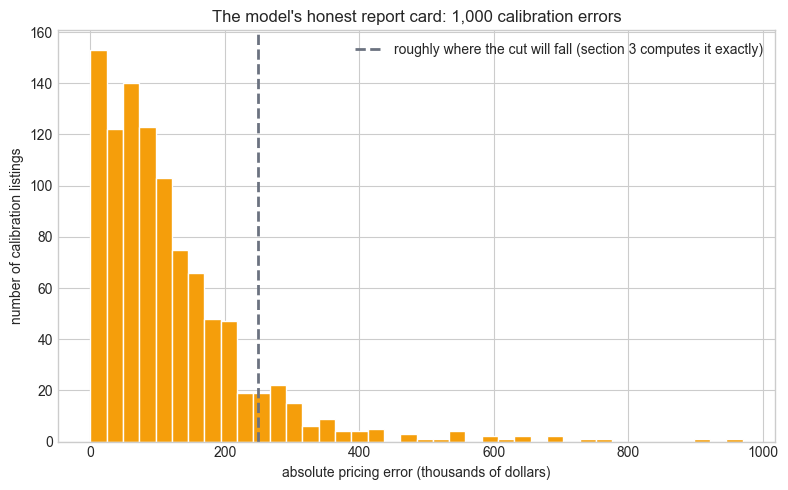

In [4]:
# Step 1: train on the training slice only. Same base model as the whole series,
# sklearn defaults, so widths and coverages stay comparable across notebooks.
model = GradientBoostingRegressor(random_state=RANDOM_SEED)
model.fit(X_train, y_train)

# Step 2: nonconformity scores on the calibration slice - absolute errors, in $k.
# These 1,000 numbers are the model's honest report card.
scores = np.abs(y_cal - model.predict(X_cal))

train_mae = np.abs(y_train - model.predict(X_train)).mean()
print(f"mean absolute error on train:       {train_mae:5.1f}k  (the flattering number)")
print(f"mean absolute error on calibration: {scores.mean():5.1f}k  (the honest number)")
print(f"calibration errors: median {np.median(scores):.1f}k, "
      f"90th percentile {np.quantile(scores, 0.90):.1f}k, max {scores.max():.1f}k")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(scores, bins=40, color=AMBER, edgecolor="white")
ax.axvline(np.quantile(scores, 0.90), color=GRAY, linestyle="--", linewidth=2,
           label="roughly where the cut will fall (section 3 computes it exactly)")
ax.set_title("The model's honest report card: 1,000 calibration errors")
ax.set_xlabel("absolute pricing error (thousands of dollars)")
ax.set_ylabel("number of calibration listings")
ax.legend()
plt.tight_layout()
plt.show()

Two readings from this cell. First, the printout: the model's mean error on its own
training listings (105.8k) is well below its mean error on calibration listings (117.6k) —
the same optimism gap that sank notebook 01, now measured instead of trusted. Nothing about
the model changed between those two lines; only the honesty of the measurement did. Second,
the histogram: calibration errors pile up below the 88.9k median and trail off into a long
right tail of listings the model mispriced by hundreds of thousands — the worst by 970.2k.
The dashed line sits near the 90th percentile of these errors, at 249.7k — the width that
nine in ten honest errors stay under. That is *almost* the threshold we want. What the
histogram does not tell you is anything about any individual future listing: it describes
how wrong this model tends to be on average over fresh Riverton homes, nothing more.

## 3. The careful quantile

Here is the line everyone writes first:

```python
# The obvious move - and quietly wrong:
q_naive = np.quantile(scores, 0.90)   # "the value 90% of calibration errors stay under"
```

It looks unimpeachable and it systematically undercovers — worst when the calibration set
is small (field guide §1). The flaw is an off-by-one in *who is being ranked*. When a new
listing arrives tomorrow, its error joins the leaderboard alongside the 1,000 calibration
errors: there are `n + 1` exchangeable players, not `n` — exchangeable in the plain sense
that any of the `n + 1` errors is equally likely to end up at any rank on that leaderboard.
For the new error to be caught by
our threshold at least 90% of the time, the threshold must sit at rank
$\lceil (n+1)(1-\alpha) \rceil$ among the `n` calibration scores — in words: sort the
calibration errors and take the *ceiling of (n+1) times 0.9*-th smallest, which for
`n = 1000` is the 901st smallest, not the 900th. Here $n$ is the number of calibration
scores, $\alpha$ is the miscoverage budget, and $\lceil \cdot \rceil$ means "round up".
The `+1` is the seat we reserve at the table for tomorrow's listing. Why the newcomer's
rank is uniform — and why that single fact proves the guarantee — is the whole story of
notebook 03; today we just implement it correctly:

In [5]:
alpha = 0.10  # the miscoverage budget: we are buying 90% target coverage

# The corrected quantile - this exact idiom appears in every notebook of the series.
n = len(scores)
q_level = math.ceil((n + 1) * (1 - alpha)) / n
assert q_level <= 1.0, "Calibration set too small for this alpha - the honest interval is infinite (field guide S1)"
q_hat = np.quantile(scores, q_level, method="higher")

# Committing the naive version too, so we can watch the difference.
q_naive = np.quantile(scores, 1 - alpha)

print(f"calibration scores: n = {n}")
print(f"rank needed: ceil((n+1)(1-alpha)) = {math.ceil((n + 1) * (1 - alpha))}"
      f" of {n}  ->  quantile level {q_level:.3f}")
print(f"q_naive (plain 90th percentile):        {q_naive:.2f}k")
print(f"q_hat   (corrected, method='higher'):   {q_hat:.2f}k")

calibration scores: n = 1000
rank needed: ceil((n+1)(1-alpha)) = 901 of 1000  ->  quantile level 0.901
q_naive (plain 90th percentile):        249.67k
q_hat   (corrected, method='higher'):   251.35k


This is **the corrected quantile** — the careful quantile the section title promised,
under the name the rest of the series uses for it. It lands at 251.35k against the naive
249.67k — a difference of under
two thousand dollars, which is exactly the point: the correction is cheap here because
`n = 1000` is comfortable, yet it is the difference between "coverage at least 90%,
provably" and "coverage approximately 90%, hopefully". Two implementation details
carry the guarantee. The `math.ceil` picks the rank; `method="higher"` tells numpy to
return an actual calibration score at or above that rank instead of interpolating between
two scores — interpolation would slide the threshold slightly down and quietly reintroduce
the undercoverage we just paid to remove. One nuance for the record: numpy's quantile grid
means `method="higher"` can land one sorted score *above* the exact
$\lceil (n+1)(1-\alpha) \rceil$-th rank — here it returns the 902nd smallest score, not
the 901st — buying up to one extra seat's worth, `1/(n+1)`, of harmless conservatism.
With small calibration sets the gap stops being
cosmetic: at `n = 20`, the corrected rank is `ceil(21 * 0.9) = 19` of 20, quantile level
0.95 — five percentile points above naive.

One caution before moving on: the assertion in that cell is not decoration. The corrected
rank can *exceed* `n`, and when it does, no finite threshold is honest. Let us trip it on
purpose:

In [6]:
# Committing the mistake on purpose: promise 99% coverage from 50 calibration listings.
n_tiny, alpha_tiny = 50, 0.01
rank_needed = math.ceil((n_tiny + 1) * (1 - alpha_tiny))
q_level_tiny = rank_needed / n_tiny
print(f"rank needed: ceil((50+1)(1-0.01)) = {rank_needed} of {n_tiny}"
      f"  ->  quantile level {q_level_tiny:.2f}")

try:
    assert q_level_tiny <= 1.0, "Calibration set too small for this alpha - the honest interval is infinite (field guide S1)"
except AssertionError as err:
    print(f"AssertionError: {err}")

rank needed: ceil((50+1)(1-0.01)) = 51 of 50  ->  quantile level 1.02
AssertionError: Calibration set too small for this alpha - the honest interval is infinite (field guide S1)


The recipe asks for the 51st smallest of 50 scores, which does not exist: with only 50
held-out errors, the only interval that honestly delivers a 99% promise is
$(-\infty, +\infty)$. The rule of thumb falls straight out of the arithmetic: you need at
least $(1-\alpha)/\alpha$ calibration points — 9 for a 90% promise, 99 for 99% — before a
finite honest interval exists at all, and considerably more before it is *stable*
(field guide §4; notebook 03 shows the realized coverage of small calibration sets swinging
like a lottery). When this assertion fires in production, the fix is more calibration data
or a humbler alpha — never `min(q_level, 1.0)`, which converts an honest infinity into a
quiet lie.

## 4. Fifteen lines, one promise

Every piece is on the table: a three-way split, a fitted model, a weirdness meter, a
careful quantile. Here is the entire method assembled in one cell — fifteen lines, plain
numpy, no functions, no framework. Lines 1 to 3 reproduce the exact split from section 1
(same seed, same shuffle), so every number below matches the pieces we built one at a time.

In [7]:
rng = np.random.default_rng(RANDOM_SEED)                          # 1. one seeded shuffle
idx = rng.permutation(len(y_all))                                 # 2. shuffle the listings
train, cal, test = idx[:2000], idx[2000:3000], idx[3000:]         # 3. three-way split
model = GradientBoostingRegressor(random_state=RANDOM_SEED)       # 4. any model at all
model.fit(X_all[train], y_all[train])                             # 5. fit on train only
scores = np.abs(y_all[cal] - model.predict(X_all[cal]))           # 6. weirdness meter
n = len(scores)                                                   # 7. calibration size
q_level = math.ceil((n + 1) * (1 - alpha)) / n                    # 8. corrected level
q_hat = np.quantile(scores, q_level, method="higher")             # 9. careful quantile
y_hat = model.predict(X_all[test])                                # 10. point predictions
lo, hi = y_hat - q_hat, y_hat + q_hat                             # 11. the interval
covered = (lo <= y_all[test]) & (y_all[test] <= hi)               # 12. truth inside?
coverage = covered.mean()                                         # 13. batting average
width = (hi - lo).mean()                                          # 14. cost of the promise
print(f"coverage: {coverage:.3f}   average width: {width:.1f}k")  # 15. the receipt

coverage: 0.901   average width: 502.7k


Empirical coverage — notebook 01's scorecard: the fraction of the 1,000 test listings whose
true sale price landed inside its interval — comes out at 0.901, within noise of the 0.90
target. How much
noise is "within noise"? A test set of 1,000 listings measures a true coverage of 0.90 with
a standard error of about $\sqrt{0.9 \times 0.1 / 1000} \approx 0.0095$, so anything in
roughly 0.88 to 0.92 is consistent with the promise; theory puts the *expected* coverage
at 0.90 or a whisker above — about 0.90 + 1/1001 for the exact rank, plus at most another
1/1001 of harmless conservatism from the rounding-up numpy idiom (section 3). The price of
the promise is the width: every
interval extends q_hat = 251.4k on each side of the predicted price, 502.7 thousand
dollars end to end, the same for every home — this market's noise is genuinely large, and
an honest interval says so.

Read the receipt for what it is not, too. It does not say each individual interval has a
90% chance of being right — coverage is a batting average over many future listings, not a
promise about this at-bat (notebook 03 makes that distinction precise). And the roughly one
miss in ten is not a defect to be patched: alpha is a budget we chose. A system that missed
*nobody* would be suspicious — it would mean we bought far more width than we asked for.

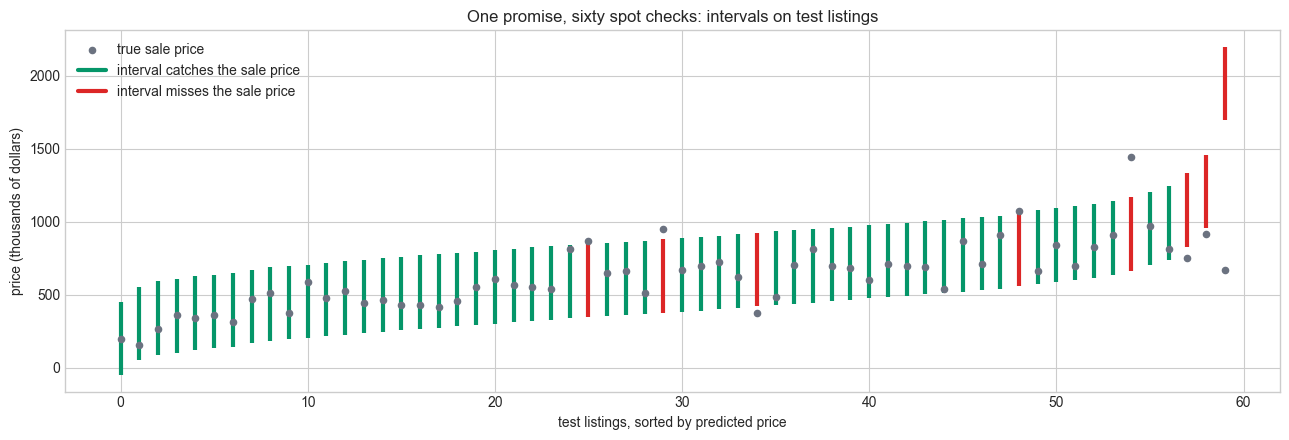

missed in this sample of 60: 8
missed in the full test set: 99 of 1000 (9.9%)
average predicted price of missed listings: 890k vs 652k overall


In [8]:
# Sixty test listings spread evenly across the predicted-price range,
# so the eye can check the promise one bar at a time.
order = np.argsort(y_hat)
show = order[np.linspace(0, len(order) - 1, 60).astype(int)]
xs = np.arange(len(show))
bar_colors = np.where(covered[show], GREEN, RED)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.vlines(xs, lo[show], hi[show], color=bar_colors, linewidth=3)
ax.scatter(xs, y_test[show], color=GRAY, s=20, zorder=3, label="true sale price")
ax.plot([], [], color=GREEN, linewidth=3, label="interval catches the sale price")
ax.plot([], [], color=RED, linewidth=3, label="interval misses the sale price")
ax.set_title("One promise, sixty spot checks: intervals on test listings")
ax.set_xlabel("test listings, sorted by predicted price")
ax.set_ylabel("price (thousands of dollars)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

missed_shown = int((~covered[show]).sum())
print(f"missed in this sample of 60: {missed_shown}")
print(f"missed in the full test set: {int((~covered).sum())} of {len(covered)} "
      f"({1 - coverage:.1%})")
print(f"average predicted price of missed listings: {y_hat[~covered].mean():.0f}k "
      f"vs {y_hat.mean():.0f}k overall")

Eight red bars in sixty, where the budget predicts six — spot checks this small wobble
(the standard deviation on sixty draws is about 2.3 misses), and the full test set is the
real scorecard: 99 of 1,000 missed, 9.9%, right on budget. The picture also shows what
"one width for everyone" means: every bar is the same 502.7k tall, from the cheapest flat
on the left to the priciest villa on the right — and the leftmost interval even dips below
zero dollars, a lower bound no listing can ever touch, because a constant ±251k width has
no idea that cheap homes cannot be that wrong. One printout below the plot deserves a
careful reading: the listings we miss are not scattered evenly — the average predicted
price of a missed listing is 890k against 652k overall. The simulator told us why: bigger
homes carry noisier prices, and a one-size interval must under-serve the wild end to
over-serve the tame end. The overall average — what section 7 will name marginal
coverage — holds; the *distribution* of the misses is
lopsided. That is not a bug in split conformal, it is a limitation of this score, and it
is the entire subject of notebook 05 (field guide §3).

## 5. The promise survives a bad model

The claim in section 2 was "for any model". That is worth a demonstration rather than a
footnote, because it is the part practitioners disbelieve first. We run the identical
recipe twice: once with a deliberately feeble model — a boosting ensemble cut down to two
depth-1 stumps, a "model" that gets to ask exactly two yes/no questions about a home before
quoting a price — and once with our decent default. Same split, same score, same careful
quantile.

In [9]:
contenders = {
    "weak (2 stumps, depth 1)": GradientBoostingRegressor(
        n_estimators=2, max_depth=1, random_state=RANDOM_SEED),
    "decent (sklearn defaults)": GradientBoostingRegressor(random_state=RANDOM_SEED),
}

rows = []
for name, m in contenders.items():
    m.fit(X_train, y_train)
    s = np.abs(y_cal - m.predict(X_cal))            # same weirdness meter
    n_m = len(s)
    q_level_m = math.ceil((n_m + 1) * (1 - alpha)) / n_m
    q = np.quantile(s, q_level_m, method="higher")  # same careful quantile
    pred = m.predict(X_test)
    rows.append({
        "model": name,
        "test MAE ($k)": np.abs(y_test - pred).mean(),
        "coverage": ((pred - q <= y_test) & (y_test <= pred + q)).mean(),
        "average width ($k)": 2 * q,
    })

report = pd.DataFrame(rows).set_index("model")
report.round(3)

,test MAE ($k),coverage,average width ($k)
model,,,
"weak (2 stumps, depth 1)",188.599,0.893,704.370
decent (sklearn defaults),118.386,0.901,502.696


Both rows keep the promise: the weak model covers 0.893 and the decent one 0.901 — both
within noise of 0.90. What separates them is everything else. The weak model's test MAE is
about 60% worse (188.6k vs 118.4k), and conformal makes it pay in the only honest
currency: its intervals are 704.4k wide against 502.7k — an extra 200 thousand dollars of
admitted uncertainty on every single quote. Coverage is *free* — any model, even a
two-question one, gets it, because the calibration step simply measures whatever errors
the model actually makes and prices the interval accordingly. Narrow intervals are
*earned* by a model that makes small errors (field guide §5). This is also a free
diagnostic: Lei et al. (2018), the paper that made split conformal mainstream, explicitly
recommend interval width as a model-comparison tool — width tracks test error, so "make
the band narrower" and "make the model better" are the same instruction. What this table
does *not* license: declaring victory because coverage hit 90%. Coverage never
discriminates between these two models; only width does.

## 6. What alpha buys

Alpha is a dial, not a constant of nature. The desk asked for 90%, but it is worth knowing
the price list before the negotiation: we rerun the quantile step at four budgets — the
model, split, and scores never change — and read off what each level of certainty costs.

In [10]:
rows = []
for a in [0.20, 0.10, 0.05, 0.01]:
    n_a = len(scores)
    q_level_a = math.ceil((n_a + 1) * (1 - a)) / n_a
    assert q_level_a <= 1.0, "Calibration set too small for this alpha - the honest interval is infinite (field guide S1)"
    q_a = np.quantile(scores, q_level_a, method="higher")
    rows.append({
        "alpha": a,
        "target coverage": 1 - a,
        "achieved coverage": ((y_hat - q_a <= y_test) & (y_test <= y_hat + q_a)).mean(),
        "average width ($k)": 2 * q_a,
    })

sweep = pd.DataFrame(rows).set_index("alpha")
sweep.round(3)

,target coverage,achieved coverage,average width ($k)
alpha,,,
0.20,0.80,0.781,356.264
0.10,0.90,0.901,502.696
0.05,0.95,0.937,623.019
0.01,0.99,0.993,1241.043


The coverage column does its job at every budget — each achieved value sits within two
percentage points of its target (the lowest reading, 0.781 against a 0.80 target, is just
over one combined standard error of test-plus-calibration noise, not a violation), which
is the guarantee retargeting itself four times in a row. The width column is the price list, and it is
brutally nonlinear: moving from 80% to 90% certainty costs about 146k of extra width,
while moving from 95% to 99% costs about 618k — four times the price for less than half
the certainty gain. The last percentage points are the most expensive because they are
priced by the far tail of the error distribution — the handful of calibration listings the
model mispriced most badly set the width for everyone.

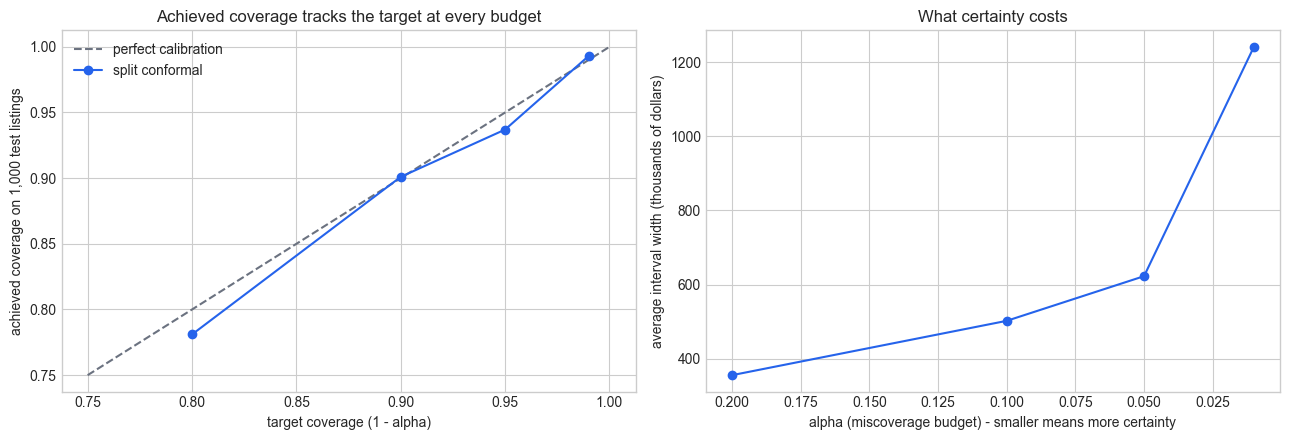

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot([0.75, 1.0], [0.75, 1.0], color=GRAY, linestyle="--", label="perfect calibration")
axes[0].plot(sweep["target coverage"], sweep["achieved coverage"],
             color=BLUE, marker="o", label="split conformal")
axes[0].set_title("Achieved coverage tracks the target at every budget")
axes[0].set_xlabel("target coverage (1 - alpha)")
axes[0].set_ylabel("achieved coverage on 1,000 test listings")
axes[0].legend()

axes[1].plot(sweep.index, sweep["average width ($k)"], color=BLUE, marker="o")
axes[1].invert_xaxis()  # certainty increases to the right
axes[1].set_title("What certainty costs")
axes[1].set_xlabel("alpha (miscoverage budget) - smaller means more certainty")
axes[1].set_ylabel("average interval width (thousands of dollars)")

plt.tight_layout()
plt.show()

The left panel is the four achieved coverages hugging the gray diagonal — the guarantee is
not a property of alpha = 0.10 specifically, it retargets to whatever budget you set. The
right panel is the same table drawn as a curve, and its shape is the useful message for the
business: a gentle climb through the easy budgets, then bending sharply upward as alpha
approaches zero. When the desk inevitably asks "can we have 99%?", the answer is yes,
mechanically, today — at 1,241k of width, an interval wider than two median Riverton
homes, which stops being a price range and becomes a shrug. The chart does not say 99% is
wrong; it says certainty is bought with width, and the desk should choose the trade
knowingly.

## 7. The fine print

Split conformal's guarantee is real, but it is a specific promise, and quoting it beyond
its terms is how statistics theatre starts. Three clauses, one sentence each:

- The 90% is **marginal coverage** — an average over many future listings — not a
  per-house probability, so it can be 98% on flats and 70% on villas and still be exactly
  right (notebook 03, field guide §3).
- It assumes tomorrow's listings and today's calibration listings are exchangeable —
  shuffled from the same deck, no regime change, no time trend — and it fails silently when
  that breaks (notebook 07, field guide §6).
- The width is one number for every house — suspicious on its face, since villas are wilder
  than flats — and fixing that without losing the guarantee is notebook 05's job.

The method we built deserves its proper name: **split conformal prediction**, also called
inductive conformal prediction in the older literature. It is the industry workhorse for
one blunt reason: it needs exactly *one* model fit, ever. Lei et al. (2018) introduced it
to mainstream statistics as a method that "seems to have been overlooked" — a fifteen-line
technique hiding in plain sight for two decades. Its cousins that spend more compute to
waste less data (full conformal, jackknife+, CV+) are notebook 06's subject.

## 8. Common mistakes to avoid

1. **Calibrating on training residuals.** The model's own training errors are optimistically
   small; thresholds built from them undercover on fresh data. Notebook 01 committed this
   crime in full; the calibration set must be untouched by training, feature selection, and
   tuning (field guide §2).
2. **Using the naive quantile.** `np.quantile(scores, 0.90)` undercovers systematically,
   worst at small `n`. Always `math.ceil((n + 1) * (1 - alpha)) / n` with
   `method="higher"` (field guide §1).
3. **Tuning on the calibration set.** The moment hyperparameters are chosen to look good on
   the calibration listings, those errors are flattering and the guarantee is void — that
   is a validation set's job, and the two must be different data.
4. **Clipping past the assertion.** If `ceil((n + 1) * (1 - alpha)) > n`, the honest
   interval is infinite; capping `q_level` at 1.0 silently converts "we cannot promise
   this" into a fake promise (field guide §1). And a calibration set that barely clears the
   bar still makes realized coverage a lottery ticket (field guide §4).
5. **Reporting coverage without width.** Coverage alone is unfalsifiable praise — any model
   achieves it. Quote coverage and average width together, and treat width as the model
   quality metric (field guide §5, §12).

## 9. What to say in the business review

**Strong version**

> For 90% of the homes we price, the true sale price falls inside the quoted range. We
> verified this on 1,000 held-out listings: 90.1% landed inside, and the range averages
> plus or minus about <span>$</span>251k. The 10% of misses is a budget we chose, not a defect — we can
> tighten it to 5% or 1% today, at a cost of widening the total range to roughly <span>$</span>623k or
> <span>$</span>1.24M, and that trade is the desk's call, not the model's.

**Weak version**

> The pricing model is now 90% accurate, so the desk can trust the ranges.

The weak version confuses coverage with accuracy, hides the width entirely, presents the
one-in-ten misses as a flaw someone will later have to explain, and promises trust on
individual houses that a marginal guarantee does not underwrite.

### The one-line summary

Split conformal prediction turns any point-price model into a promise-keeping range model:
hold out listings the model never saw, measure how wrong it tends to be, and quote the
careful quantile of that wrongness as your width. The model can be weak, the prices can be
weird, and the promise still holds — only the width remembers how good your model was.

The guarantee costs one data split and one careful quantile; everything else is engineering.